# 📘 Complete Sklearn Preprocessing — Step by Step

This notebook covers **every concept** from the slides in order:

| Part | Topic |
|------|-------|
| 0 | Setup & Dataset Loading |
| 1 | Feature Extraction (DictVectorizer, FeatureHasher) |
| 2 | Data Cleaning (SimpleImputer, KNNImputer, MissingIndicator) |
| 3 | Numeric Transformers (StandardScaler, MinMaxScaler, MaxAbsScaler, FunctionTransformer, PolynomialFeatures, KBinsDiscretizer) |
| 4 | Categorical Transformers (OneHotEncoder, LabelEncoder, OrdinalEncoder, LabelBinarizer, MultiLabelBinarizer) |
| 5 | Feature Selection (VarianceThreshold, Univariate, RFE, SelectFromModel, SFS) |
| 6 | ColumnTransformer & TransformedTargetRegressor |
| 7 | Dimensionality Reduction (PCA) |
| 8 | Pipelines & FeatureUnion |

---
## 🔧 PART 0 — Setup & Dataset Loading

In [1]:
# ── Core imports ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✅ Core libraries imported')

✅ Core libraries imported


In [2]:
# ── Dataset 1: Titanic (missing values, mixed types) ──────────────
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url_titanic)
print('Titanic shape:', titanic.shape)
titanic.head()

Titanic shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ── Dataset 2: California Housing (numeric, missing values) ───────
url_housing = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
housing = pd.read_csv(url_housing)
print('Housing shape:', housing.shape)
housing.head()

Housing shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# ── Dataset 3: Built-in sklearn datasets ──────────────────────────
from sklearn.datasets import load_iris, load_breast_cancer, load_wine

iris = load_iris(as_frame=True)
cancer = load_breast_cancer(as_frame=True)
wine = load_wine(as_frame=True)

print('Iris:',   iris.data.shape)
print('Cancer:', cancer.data.shape)
print('Wine:',   wine.data.shape)

Iris: (150, 4)
Cancer: (569, 30)
Wine: (178, 13)


---
## 📦 PART 1 — Feature Extraction

### 1.1 DictVectorizer
Converts a list of dicts (feature_name → value) into a numeric matrix.

In [5]:
from sklearn.feature_extraction import DictVectorizer

data = [
    {'city': 'Mumbai',  'temp': 35, 'humidity': 80},
    {'city': 'Delhi',   'temp': 40, 'humidity': 60},
    {'city': 'Mumbai',  'temp': 33, 'humidity': 85},
    {'city': 'Chennai', 'temp': 38, 'humidity': 75},
]

dv = DictVectorizer(sparse=False)
X_dv = dv.fit_transform(data)

print('Feature names:', dv.get_feature_names_out())
print('Shape:', X_dv.shape)
print()
print(pd.DataFrame(X_dv, columns=dv.get_feature_names_out()))

Feature names: ['city=Chennai' 'city=Delhi' 'city=Mumbai' 'humidity' 'temp']
Shape: (4, 5)

   city=Chennai  city=Delhi  city=Mumbai  humidity  temp
0           0.0         0.0          1.0      80.0  35.0
1           0.0         1.0          0.0      60.0  40.0
2           0.0         0.0          1.0      85.0  33.0
3           1.0         0.0          0.0      75.0  38.0


### 1.2 FeatureHasher
High-speed, low-memory alternative — uses a hash function to map features to columns. **No inverse_transform.**

In [6]:
from sklearn.feature_extraction import FeatureHasher

# Same data as above
fh = FeatureHasher(n_features=8, input_type='dict')
X_fh = fh.fit_transform(data)

print('Type:', type(X_fh))          # scipy sparse matrix
print('Shape:', X_fh.shape)
print('Dense view:')
print(X_fh.toarray())
print()
print('⚠️  No get_feature_names_out() — hashing is not invertible')

Type: <class 'scipy.sparse._csr.csr_matrix'>
Shape: (4, 8)
Dense view:
[[ 0.  0.  0.  0.  0. 80.  0. 34.]
 [ 0. -1.  0.  0.  0. 60.  0. 40.]
 [ 0.  0.  0.  0.  0. 85.  0. 32.]
 [ 0. -1.  0.  0.  0. 75.  0. 38.]]

⚠️  No get_feature_names_out() — hashing is not invertible


### DictVectorizer vs FeatureHasher — Key Differences

| | DictVectorizer | FeatureHasher |
|---|---|---|
| Speed | Slower | **Faster** |
| Memory | Higher | **Lower** |
| Invertible | ✅ Yes | ❌ No |
| Hash collisions | No | Possible |

---
## 🧹 PART 2 — Data Cleaning (Imputation)

### 2.1 Explore Missing Values in Titanic

          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


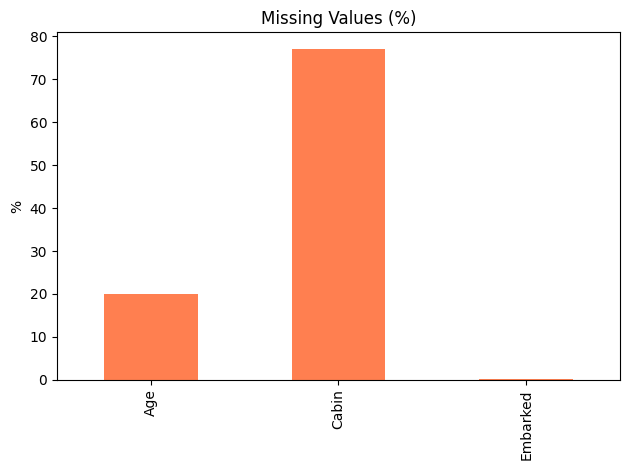

In [7]:
# Inspect missing values
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(2)

df_missing = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(df_missing[df_missing['Missing Count'] > 0])

# Visualise
df_missing[df_missing['Missing Count'] > 0]['Missing %'].plot(
    kind='bar', color='coral', title='Missing Values (%)')
plt.ylabel('%')
plt.tight_layout()
plt.show()

### 2.2 SimpleImputer — mean / median / most_frequent / constant

In [8]:
from sklearn.impute import SimpleImputer

# Select numeric columns with missing values
X_num = titanic[['Age', 'Fare']].copy()
print('Before imputation:\n', X_num.isnull().sum())

# ── Strategy: mean ────────────────────────────────────────────────
si_mean = SimpleImputer(strategy='mean')
X_mean = si_mean.fit_transform(X_num)
print('\nLearned means:', si_mean.statistics_)

# ── Strategy: median ──────────────────────────────────────────────
si_median = SimpleImputer(strategy='median')
X_median = si_median.fit_transform(X_num)
print('Learned medians:', si_median.statistics_)

# ── Strategy: most_frequent (for categorical) ─────────────────────
X_cat = titanic[['Embarked']].copy()
si_freq = SimpleImputer(strategy='most_frequent')
X_freq = si_freq.fit_transform(X_cat)
print('Most frequent Embarked:', si_freq.statistics_)

# ── Strategy: constant ────────────────────────────────────────────
si_const = SimpleImputer(strategy='constant', fill_value=-999)
X_const = si_const.fit_transform(X_num)
print('After constant fill:\n', pd.DataFrame(X_const, columns=['Age','Fare']).isnull().sum())

Before imputation:
 Age     177
Fare      0
dtype: int64

Learned means: [29.69911765 32.20420797]
Learned medians: [28.     14.4542]
Most frequent Embarked: ['S']
After constant fill:
 Age     0
Fare    0
dtype: int64


### 2.3 KNNImputer — fills missing values using k-nearest neighbors

In [9]:
from sklearn.impute import KNNImputer

# Create a small example to understand the algorithm clearly
X_demo = np.array([
    [1, 2, np.nan],
    [3, 4, 3],
    [np.nan, 6, 5],
    [8, 8, 7],
])

print('Before KNN Imputation:')
print(X_demo)

knni = KNNImputer(n_neighbors=2, weights='uniform')
X_knn = knni.fit_transform(X_demo)

print('\nAfter KNN Imputation (n_neighbors=2):')
print(X_knn)
print()
print('Row 0, col 2: was NaN → filled with mean of 2 nearest rows in col 2')
print('Row 2, col 0: was NaN → filled with mean of 2 nearest rows in col 0')

Before KNN Imputation:
[[ 1.  2. nan]
 [ 3.  4.  3.]
 [nan  6.  5.]
 [ 8.  8.  7.]]

After KNN Imputation (n_neighbors=2):
[[1.  2.  4. ]
 [3.  4.  3. ]
 [5.5 6.  5. ]
 [8.  8.  7. ]]

Row 0, col 2: was NaN → filled with mean of 2 nearest rows in col 2
Row 2, col 0: was NaN → filled with mean of 2 nearest rows in col 0


In [10]:
# Apply KNNImputer on Titanic Age column
X_age = titanic[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']].copy()
print('Missing before:', X_age.isnull().sum())

knni_titanic = KNNImputer(n_neighbors=5)
X_age_imputed = knni_titanic.fit_transform(X_age)

print('Missing after: ', pd.DataFrame(X_age_imputed).isnull().sum().sum())
print('KNN uses neighboring passenger profiles to estimate missing Age')

Missing before: Age       177
Pclass      0
SibSp       0
Parch       0
Fare        0
dtype: int64
Missing after:  0
KNN uses neighboring passenger profiles to estimate missing Age


### 2.4 MissingIndicator — preserve missingness as a feature

In [11]:
from sklearn.impute import MissingIndicator

X_demo = np.array([
    [1,   2,    np.nan],
    [3,   np.nan, 3  ],
    [np.nan, 6,  5   ],
    [8,   8,    7    ],
])

mi = MissingIndicator()
mask = mi.fit_transform(X_demo)

print('Original data:')
print(X_demo)
print()
print('Missing indicator (True = was missing):')
print(mask)
print()
print('Feature indices that had any missing values:', mi.features_)
print('💡 Tip: Append this mask to your feature matrix to capture')
print('       the PATTERN of missingness as extra columns')

Original data:
[[ 1.  2. nan]
 [ 3. nan  3.]
 [nan  6.  5.]
 [ 8.  8.  7.]]

Missing indicator (True = was missing):
[[False False  True]
 [False  True False]
 [ True False False]
 [False False False]]

Feature indices that had any missing values: [0 1 2]
💡 Tip: Append this mask to your feature matrix to capture
       the PATTERN of missingness as extra columns


---
## 📐 PART 3 — Numeric Transformers

### 3.1 Why Feature Scaling Matters

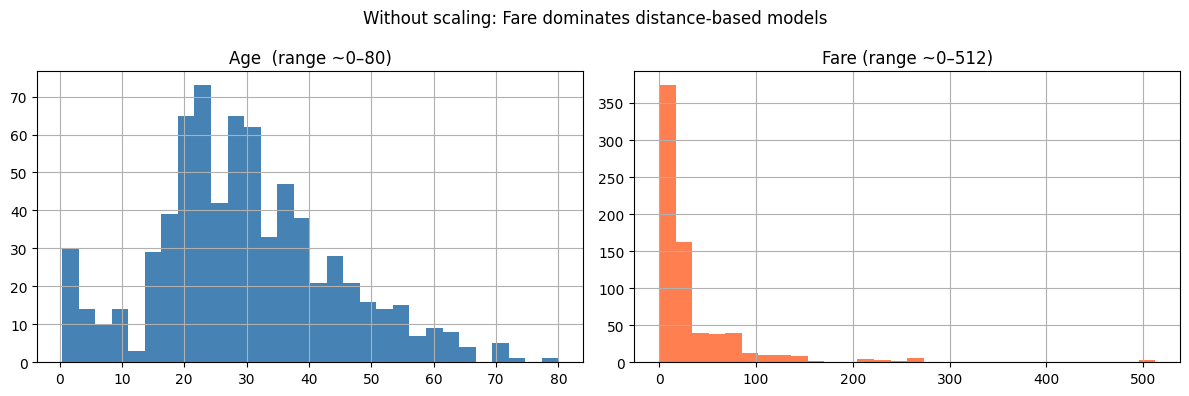

In [12]:
# Visualise scale difference before scaling
X_scale_demo = titanic[['Age', 'Fare']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X_scale_demo['Age'].hist(ax=axes[0],  bins=30, color='steelblue')
axes[0].set_title('Age  (range ~0–80)')
X_scale_demo['Fare'].hist(ax=axes[1], bins=30, color='coral')
axes[1].set_title('Fare (range ~0–512)')
plt.suptitle('Without scaling: Fare dominates distance-based models')
plt.tight_layout()
plt.show()

### 3.2 StandardScaler  —  x' = (x − μ) / σ  →  mean=0, std=1

In [13]:
from sklearn.preprocessing import StandardScaler

X = X_scale_demo.values

ss = StandardScaler()
X_ss = ss.fit_transform(X)

print('Learned mean  (μ):', ss.mean_.round(3))
print('Learned std   (σ):', ss.scale_.round(3))
print()
print(f'After StandardScaler:')
print(f'  Age  — mean: {X_ss[:,0].mean():.4f},  std: {X_ss[:,0].std():.4f}')
print(f'  Fare — mean: {X_ss[:,1].mean():.4f},  std: {X_ss[:,1].std():.4f}')

Learned mean  (μ): [29.699 34.695]
Learned std   (σ): [14.516 52.882]

After StandardScaler:
  Age  — mean: 0.0000,  std: 1.0000
  Fare — mean: -0.0000,  std: 1.0000


### 3.3 MinMaxScaler  —  x' = (x − min) / (max − min)  →  range [0, 1]

In [14]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
X_mms = mms.fit_transform(X)

print('data_min_:', mms.data_min_.round(3))
print('data_max_:', mms.data_max_.round(3))
print()
print(f'After MinMaxScaler:')
print(f'  Age  — min: {X_mms[:,0].min():.4f},  max: {X_mms[:,0].max():.4f}')
print(f'  Fare — min: {X_mms[:,1].min():.4f},  max: {X_mms[:,1].max():.4f}')

data_min_: [0.42 0.  ]
data_max_: [ 80.    512.329]

After MinMaxScaler:
  Age  — min: 0.0000,  max: 1.0000
  Fare — min: 0.0000,  max: 1.0000


### 3.4 MaxAbsScaler  —  x' = x / MaxAbsoluteValue  →  range [−1, 1]
Preserves zero entries → ideal for **sparse data**.

In [15]:
from sklearn.preprocessing import MaxAbsScaler

X_signed = np.array([[-3, 2], [-1, 0], [0, 1], [3, -4]], dtype=float)
print('Original (with negatives):')
print(X_signed)

mas = MaxAbsScaler()
X_mas = mas.fit_transform(X_signed)

print('\nMaxAbsoluteValues per column:', mas.max_abs_)
print('\nAfter MaxAbsScaler (range −1 to 1):')
print(X_mas)
print(f'  Min: {X_mas.min():.1f},  Max: {X_mas.max():.1f}')

Original (with negatives):
[[-3.  2.]
 [-1.  0.]
 [ 0.  1.]
 [ 3. -4.]]

MaxAbsoluteValues per column: [3. 4.]

After MaxAbsScaler (range −1 to 1):
[[-1.          0.5       ]
 [-0.33333333  0.        ]
 [ 0.          0.25      ]
 [ 1.         -1.        ]]
  Min: -1.0,  Max: 1.0


### 3.5 Visual Comparison: StandardScaler vs MinMaxScaler vs MaxAbsScaler

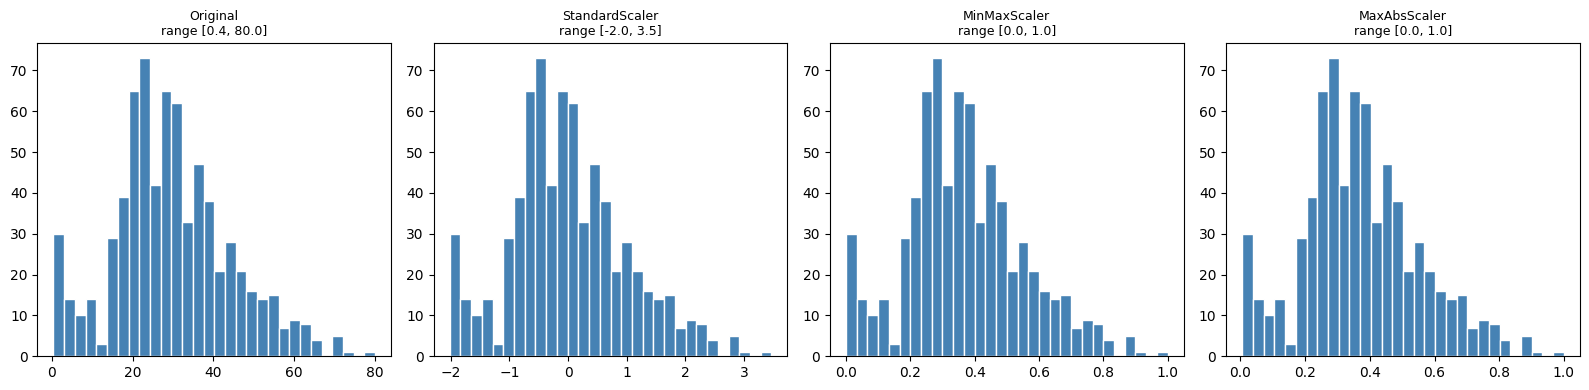

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

X_vis = titanic[['Age']].dropna().values

scalers = {
    'Original':         X_vis,
    'StandardScaler':   StandardScaler().fit_transform(X_vis),
    'MinMaxScaler':     MinMaxScaler().fit_transform(X_vis),
    'MaxAbsScaler':     MaxAbsScaler().fit_transform(X_vis),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'{name}\nrange [{data.min():.1f}, {data.max():.1f}]', fontsize=9)
plt.tight_layout()
plt.show()

### 3.6 FunctionTransformer — apply any custom function

AttributeError: 'DataFrame' object has no attribute 'ravel'

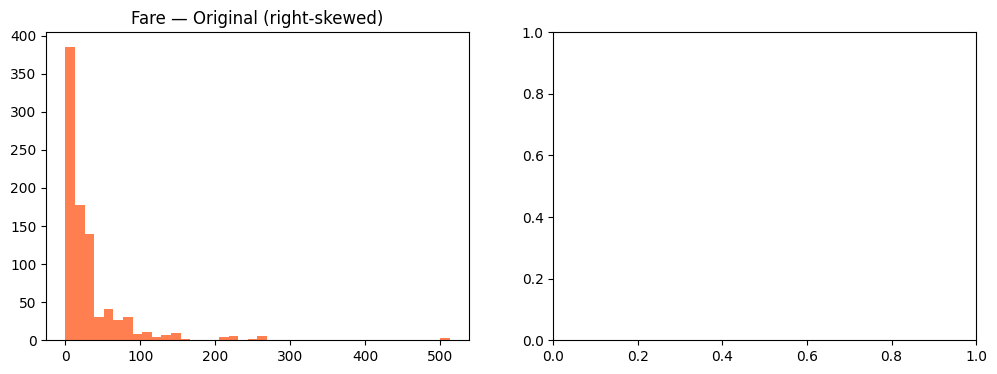

In [17]:
from sklearn.preprocessing import FunctionTransformer

X_fare = titanic[['Fare']].dropna()

# Log transform to reduce right skew
log_transformer = FunctionTransformer(np.log1p)   # log(1+x) avoids log(0)
X_log = log_transformer.fit_transform(X_fare)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_fare.values.ravel(), bins=40, color='coral')
axes[0].set_title('Fare — Original (right-skewed)')
axes[1].hist(X_log.ravel(), bins=40, color='mediumseagreen')
axes[1].set_title('Fare — After log1p transform')
plt.tight_layout()
plt.show()

print('Skewness before:', round(float(X_fare.skew()), 3))
print('Skewness after: ', round(pd.Series(X_log.ravel()).skew(), 3))

### 3.7 PolynomialFeatures — generate interaction and power terms

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

X_poly = np.array([[2, 3], [4, 5]])
print('Input features [x1, x2]:')
print(X_poly)

for deg in [2, 3]:
    pf = PolynomialFeatures(degree=deg, include_bias=True)
    X_out = pf.fit_transform(X_poly)
    print(f'\ndegree={deg} → {X_out.shape[1]} features:')
    print('Feature names:', pf.get_feature_names_out(['x1', 'x2']))
    print(X_out)

### 3.8 KBinsDiscretizer — bin continuous feature into discrete intervals

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

X_age_arr = titanic[['Age']].dropna().values

for strategy in ['uniform', 'quantile', 'kmeans']:
    kbd = KBinsDiscretizer(n_bins=5, strategy=strategy, encode='ordinal')
    X_binned = kbd.fit_transform(X_age_arr)
    print(f'strategy={strategy!r:12s}  bin_edges={np.round(kbd.bin_edges_[0], 1)}')

# One-hot encoded version
kbd_ohe = KBinsDiscretizer(n_bins=5, strategy='quantile', encode='onehot-dense')
X_ohe_bins = kbd_ohe.fit_transform(X_age_arr)
print(f'\nOne-hot encoded shape: {X_ohe_bins.shape}  (5 bins → 5 columns)')
print(X_ohe_bins[:5])

---
## 🏷️ PART 4 — Categorical Transformers

### 4.1 OneHotEncoder — K binary columns for K unique values

In [ ]:
from sklearn.preprocessing import OneHotEncoder

X_embarked = titanic[['Embarked']].fillna('S')
print('Unique values:', X_embarked['Embarked'].unique())

ohe = OneHotEncoder(sparse_output=False)
X_ohe = ohe.fit_transform(X_embarked)

print('Categories:', ohe.categories_)
print('Shape:', X_ohe.shape)
print()
df_ohe = pd.DataFrame(X_ohe, columns=ohe.get_feature_names_out())
df_ohe['Original'] = X_embarked['Embarked'].values
print(df_ohe.drop_duplicates())

### 4.2 LabelEncoder — encode target labels 0 to K−1 (1D only)

In [ ]:
from sklearn.preprocessing import LabelEncoder

y = titanic['Embarked'].fillna('S').values
print('Original labels:', np.unique(y))

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Encoded classes:', le.classes_)
print('Mapping:         C→0, Q→1, S→2')
print('Sample original:', y[:8])
print('Sample encoded: ', y_encoded[:8])
print()
print('Inverse transform:', le.inverse_transform([0, 1, 2]))

### 4.3 OrdinalEncoder — for multi-dimensional feature matrices (2D)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

X_cat_multi = titanic[['Embarked', 'Sex']].fillna('S')
print('Sample input:')
print(X_cat_multi.head())

oe = OrdinalEncoder()
X_oe = oe.fit_transform(X_cat_multi)

print('\nCategories per column:', oe.categories_)
print('\nEncoded output (first 5 rows):')
print(pd.DataFrame(X_oe, columns=['Embarked_enc', 'Sex_enc']).head())

### 4.4 LabelBinarizer — multi-class labels → one-vs-all binary matrix

In [ ]:
from sklearn.preprocessing import LabelBinarizer

y_multi = np.array(['cat', 'dog', 'fish', 'cat', 'dog', 'fish', 'cat'])

lb = LabelBinarizer()
Y_bin = lb.fit_transform(y_multi)

print('Classes:', lb.classes_)
print('Shape:', Y_bin.shape, '← one column per class')
print()
df_lb = pd.DataFrame(Y_bin, columns=lb.classes_)
df_lb['Original'] = y_multi
print(df_lb)
print()
print('Used for one-vs-all classification when estimator')
print('does not natively support multiclass.')

### 4.5 MultiLabelBinarizer — handle samples with MULTIPLE labels

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# Each sample can belong to multiple classes
y_multi_label = [
    ('action', 'thriller'),
    ('comedy',),
    ('action', 'comedy', 'drama'),
    ('drama', 'thriller'),
    ('comedy', 'thriller'),
]

mlb = MultiLabelBinarizer()
Y_mlb = mlb.fit_transform(y_multi_label)

print('All classes:', mlb.classes_)
print('Shape:', Y_mlb.shape)
print()
df_mlb = pd.DataFrame(Y_mlb, columns=mlb.classes_)
df_mlb.index = [str(x) for x in y_multi_label]
print(df_mlb)

### 4.6 add_dummy_feature — add a column of 1s (bias term)

In [ ]:
from sklearn.preprocessing import add_dummy_feature

X_small = np.array([[1, 2], [3, 4], [5, 6]])
print('Original:', X_small)

X_dummy = add_dummy_feature(X_small)
print('After add_dummy_feature (bias column = 1 prepended):')
print(X_dummy)

---
## 🔍 PART 5 — Feature Selection

### 5.1 VarianceThreshold — remove near-zero or zero variance features

In [ ]:
from sklearn.feature_selection import VarianceThreshold

X_var = np.array([
    [0, 2, 1, 0.5],   # col 0 = constant → variance 0
    [0, 3, 2, 1.5],   # col 3 = low variance
    [0, 4, 3, 0.5],
    [0, 5, 4, 1.5],
])

print('Feature variances:', X_var.var(axis=0).round(3))

# Remove zero-variance features (default)
vt = VarianceThreshold(threshold=0.0)
X_vt = vt.fit_transform(X_var)
print(f'\nBefore: {X_var.shape[1]} features   After: {X_vt.shape[1]} features')
print('Kept feature indices:', vt.get_support(indices=True))

# Remove low-variance features (threshold > 0.5)
vt2 = VarianceThreshold(threshold=0.5)
X_vt2 = vt2.fit_transform(X_var)
print(f'With threshold=0.5 → {X_vt2.shape[1]} features kept')

### 5.2 Univariate Feature Selection — SelectKBest, SelectPercentile, GenericUnivariateSelect

In [ ]:
from sklearn.feature_selection import SelectKBest, SelectPercentile, GenericUnivariateSelect
from sklearn.feature_selection import f_classif, mutual_info_classif, chi2

X_bc = cancer.data
y_bc = cancer.target
feature_names = cancer.feature_names

print(f'Original: {X_bc.shape[1]} features')

# ── SelectKBest ───────────────────────────────────────────────────
skb = SelectKBest(score_func=f_classif, k=10)
X_skb = skb.fit_transform(X_bc, y_bc)
print(f'SelectKBest (k=10):     {X_skb.shape[1]} features')
print('Top 10:', list(feature_names[skb.get_support()]))

# ── SelectPercentile ──────────────────────────────────────────────
sp = SelectPercentile(score_func=f_classif, percentile=30)
X_sp = sp.fit_transform(X_bc, y_bc)
print(f'\nSelectPercentile (30%): {X_sp.shape[1]} features')

# ── Mutual Information ────────────────────────────────────────────
skb_mi = SelectKBest(score_func=mutual_info_classif, k=10)
X_mi = skb_mi.fit_transform(X_bc, y_bc)
print(f'\nMutual Info (k=10):     {X_mi.shape[1]} features')
print('Top 10:', list(feature_names[skb_mi.get_support()]))

In [ ]:
# Visualise F-statistic scores for all features
skb_all = SelectKBest(score_func=f_classif, k='all')
skb_all.fit(X_bc, y_bc)

scores_df = pd.DataFrame({'feature': feature_names, 'F_score': skb_all.scores_})
scores_df = scores_df.sort_values('F_score', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(range(len(scores_df)), scores_df['F_score'], color='steelblue')
plt.xticks(range(len(scores_df)), scores_df['feature'], rotation=90, fontsize=8)
plt.title('Univariate F-scores — Breast Cancer Dataset')
plt.ylabel('F-score')
plt.tight_layout()
plt.show()

### 5.3 RFE — Recursive Feature Elimination

In [ ]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# ── RFE with fixed n_features ─────────────────────────────────────
estimator = LogisticRegression(max_iter=10000)
rfe = RFE(estimator=estimator, n_features_to_select=10, step=1)
X_rfe = rfe.fit_transform(X_bc, y_bc)

print(f'RFE selected {X_rfe.shape[1]} features:')
print(list(feature_names[rfe.support_]))
print('\nFeature ranking (1 = selected):')
rank_df = pd.Series(rfe.ranking_, index=feature_names).sort_values()
print(rank_df.head(15))

In [ ]:
# ── RFECV — auto-selects optimal number via cross-validation ──────
rfecv = RFECV(estimator=LogisticRegression(max_iter=10000), step=1, cv=5)
rfecv.fit(X_bc, y_bc)

print(f'Optimal number of features: {rfecv.n_features_}')
print(f'Selected: {list(feature_names[rfecv.support_])}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'], marker='o')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Optimal={rfecv.n_features_}')
plt.xlabel('Number of features')
plt.ylabel('Cross-Val Accuracy')
plt.title('RFECV — Optimal Feature Count')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 SelectFromModel — select features above importance threshold

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_bc, y_bc)

# ── Using mean as threshold ────────────────────────────────────────
sfm_mean = SelectFromModel(rf, threshold='mean', prefit=True)
X_sfm_mean = sfm_mean.transform(X_bc)
print(f'Threshold=mean  → {X_sfm_mean.shape[1]} features')
print(list(feature_names[sfm_mean.get_support()]))

# ── Using median as threshold ──────────────────────────────────────
sfm_med = SelectFromModel(rf, threshold='median', prefit=True)
X_sfm_med = sfm_med.transform(X_bc)
print(f'\nThreshold=median → {X_sfm_med.shape[1]} features')

# ── Visualise feature importances ─────────────────────────────────
fi_df = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(14, 5))
fi_df.plot(kind='bar', color='forestgreen')
plt.axhline(rf.feature_importances_.mean(), color='red', linestyle='--', label='mean threshold')
plt.title('Random Forest Feature Importances')
plt.legend()
plt.tight_layout()
plt.show()

### 5.5 SequentialFeatureSelector (SFS) — greedy forward / backward selection

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

# Use iris (smaller dataset) for speed
X_iris = iris.data.values
y_iris = iris.target.values
iris_features = iris.data.columns.tolist()

knn = KNeighborsClassifier(n_neighbors=3)

# ── Forward Selection ─────────────────────────────────────────────
sfs_fwd = SequentialFeatureSelector(knn, n_features_to_select=2,
                                     direction='forward', cv=5)
sfs_fwd.fit(X_iris, y_iris)
print('Forward SFS selected:', [iris_features[i] for i in sfs_fwd.get_support(indices=True)])

# ── Backward Elimination ──────────────────────────────────────────
sfs_bwd = SequentialFeatureSelector(knn, n_features_to_select=2,
                                     direction='backward', cv=5)
sfs_bwd.fit(X_iris, y_iris)
print('Backward SFS selected:', [iris_features[i] for i in sfs_bwd.get_support(indices=True)])

print()
print('Note: forward ≠ backward — they can select different features!')
print('Tip: if selecting k of n features, choose direction with fewer steps')
print('     k < n/2 → forward,   k > n/2 → backward')

---
## 🔀 PART 6 — ColumnTransformer & TransformedTargetRegressor

### 6.1 ColumnTransformer — apply different transforms to different columns

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Prepare Titanic features
df = titanic[['Age', 'Fare', 'Pclass', 'Sex', 'Embarked']].copy()
df['Embarked'] = df['Embarked'].fillna('S')

numeric_features    = ['Age', 'Fare', 'Pclass']
categorical_features = ['Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore'))
])

ct = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

X_ct = ct.fit_transform(df)
print('Output shape:', X_ct.shape)
print('Numeric cols (3) + OHE cols =', X_ct.shape[1])
print('Feature names:', ct.get_feature_names_out())

### 6.2 TransformedTargetRegressor — transform the target y before fitting

In [ ]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Use housing dataset — target is median_house_value (very skewed)
house_clean = housing.dropna()
X_h = house_clean[['median_income', 'housing_median_age', 'total_rooms']].values
y_h = house_clean['median_house_value'].values

print('Target skewness (original):', round(pd.Series(y_h).skew(), 3))

# Standard regressor
lr = LinearRegression()
lr.fit(X_h, y_h)
rmse_plain = np.sqrt(mean_squared_error(y_h, lr.predict(X_h)))

# TransformedTargetRegressor with log transform
ttr = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p,
    inverse_func=np.expm1
)
ttr.fit(X_h, y_h)
rmse_log = np.sqrt(mean_squared_error(y_h, ttr.predict(X_h)))

print(f'\nRMSE (plain regressor):     ${rmse_plain:,.0f}')
print(f'RMSE (with log-y transform): ${rmse_log:,.0f}')
print()
print('The TTR automatically applies inverse_func (expm1) to predictions')
print('so predict() always returns values in the ORIGINAL target space')

---
## 📉 PART 7 — Dimensionality Reduction with PCA

PCA finds directions of maximum variance (principal components) using SVD.
Each PC is orthogonal to the previous ones.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_bc_scaled = StandardScaler().fit_transform(X_bc)

# ── Fit PCA and inspect explained variance ────────────────────────
pca_full = PCA()
pca_full.fit(X_bc_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance per PC')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o', color='coral')
plt.axhline(0.95, color='green', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Plot — Choose k here')
plt.legend()
plt.tight_layout()
plt.show()

k95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components needed for 95% variance: {k95} (out of {X_bc.shape[1]})')

In [ ]:
# ── Reduce to 2D and visualise ─────────────────────────────────────
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_bc_scaled)

print(f'Reduced: {X_bc_scaled.shape[1]} → {X_pca_2d.shape[1]} dimensions')
print(f'Variance explained by PC1+PC2: {pca_2d.explained_variance_ratio_.sum():.1%}')

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral']
for label, color in zip([0, 1], colors):
    mask = y_bc == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=color,
                alpha=0.6, label=cancer.target_names[label])
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Breast Cancer Dataset — PCA 2D Projection')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔗 PART 8 — Pipelines & FeatureUnion

### 8.1 Why use Pipeline?
All preprocessing steps must be applied **in the same order** to train and test data.
Using a Pipeline guarantees this automatically.

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

# ── Method 1: Pipeline with named steps ───────────────────────────
pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
    ('pca',     PCA(n_components=10)),
    ('clf',     LogisticRegression(max_iter=10000)),
])

pipe.fit(X_train, y_train)
print('Pipeline steps:', [name for name, _ in pipe.steps])
print('Train accuracy:', pipe.score(X_train, y_train).round(4))
print('Test  accuracy:', pipe.score(X_test,  y_test).round(4))

In [ ]:
# ── Method 2: make_pipeline (auto-names steps) ────────────────────
pipe2 = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    PCA(n_components=10),
    LogisticRegression(max_iter=10000)
)

pipe2.fit(X_train, y_train)
print('Step names (auto):', list(pipe2.named_steps.keys()))
print('Test accuracy:', pipe2.score(X_test, y_test).round(4))

In [ ]:
# ── Accessing steps in a pipeline ─────────────────────────────────
print('By name:       ', pipe['pca'])
print('By index:      ', pipe[2])
print('via .steps:    ', pipe.steps[2])
print('via .named_steps:', pipe.named_steps['pca'])

# ── Setting parameters (double underscore syntax) ─────────────────
pipe.set_params(pca__n_components=5)
print('\nAfter set_params: pca n_components =', pipe['pca'].n_components)

### 8.2 GridSearchCV over Pipeline parameters

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe_gs = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca',    PCA()),
    ('clf',    LogisticRegression(max_iter=10000)),
])

param_grid = {
    'pca__n_components': [5, 10, 15],
    'clf__C':            [0.1, 1, 10],
}

gs = GridSearchCV(pipe_gs, param_grid=param_grid, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

print('Best params:   ', gs.best_params_)
print('Best CV score: ', round(gs.best_score_, 4))
print('Test score:    ', round(gs.best_estimator_.score(X_test, y_test), 4))

### 8.3 FeatureUnion — apply transformers in parallel and concatenate outputs

In [ ]:
from sklearn.pipeline import FeatureUnion

# Branch 1: PCA to capture global structure
# Branch 2: SelectKBest to keep most discriminative raw features
# → Concatenate both for a richer feature set

fu = FeatureUnion(transformer_list=[
    ('pca',  PCA(n_components=5)),
    ('skb',  SelectKBest(f_classif, k=5)),
])

X_fu = fu.fit_transform(X_bc_scaled, y_bc)
print(f'PCA(5) + SelectKBest(5) → combined shape: {X_fu.shape}')
print('5 PCA components + 5 best raw features = 10 total')

In [ ]:
# Combine FeatureUnion inside a Pipeline
pipe_fu = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('union',  FeatureUnion([
        ('pca', PCA(n_components=5)),
        ('skb', SelectKBest(f_classif, k=5)),
    ])),
    ('clf', LogisticRegression(max_iter=10000)),
])

pipe_fu.fit(X_train, y_train)
print('Pipeline with FeatureUnion test accuracy:', pipe_fu.score(X_test, y_test).round(4))

### 8.4 Visualise a Pipeline

In [ ]:
from sklearn import set_config
set_config(display='diagram')

# This renders as an interactive HTML diagram in Jupyter
pipe_fu

---
## 🏁 PART 9 — Full End-to-End Pipeline (Titanic Survival)

Putting everything together: imputation + scaling + encoding + feature selection + model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# ── Prepare data ──────────────────────────────────────────────────
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target   = 'Survived'

df_full = titanic[features + [target]].copy()
df_full['Embarked'] = df_full['Embarked'].fillna('S')

X_full = df_full[features]
y_full = df_full[target]

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full,
                                            test_size=0.2, random_state=42)

# ── Define column groups ──────────────────────────────────────────
num_cols  = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols  = ['Pclass', 'Sex', 'Embarked']

# ── Sub-pipelines ─────────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

# ── Full pipeline ─────────────────────────────────────────────────
full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('selector',     SelectKBest(f_classif, k=8)),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42)),
])

# ── Train and evaluate ────────────────────────────────────────────
full_pipe.fit(X_tr, y_tr)

cv_scores = cross_val_score(full_pipe, X_full, y_full, cv=5)
print('5-Fold CV Scores:', cv_scores.round(4))
print(f'Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Test  Accuracy:   {full_pipe.score(X_te, y_te):.4f}')

In [ ]:
# Visualise the full pipeline diagram
set_config(display='diagram')
full_pipe

---
## 📋 Summary — What We Covered

| Part | Concept | Key Class |
|------|---------|----------|
| 1 | Feature Extraction | `DictVectorizer`, `FeatureHasher` |
| 2 | Missing Values | `SimpleImputer`, `KNNImputer`, `MissingIndicator` |
| 3 | Numeric Scaling | `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler` |
| 3 | Custom / Poly / Bins | `FunctionTransformer`, `PolynomialFeatures`, `KBinsDiscretizer` |
| 4 | Categorical Encoding | `OneHotEncoder`, `LabelEncoder`, `OrdinalEncoder`, `LabelBinarizer`, `MultiLabelBinarizer` |
| 5 | Feature Selection | `VarianceThreshold`, `SelectKBest`, `RFE`, `RFECV`, `SelectFromModel`, `SequentialFeatureSelector` |
| 6 | Column Routing | `ColumnTransformer`, `TransformedTargetRegressor` |
| 7 | Dimensionality Reduction | `PCA` |
| 8 | Chaining | `Pipeline`, `make_pipeline`, `FeatureUnion` |
| 9 | End-to-End | Full Titanic pipeline |

### Datasets Used
- **Titanic**: `https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`
- **Housing**: `https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv`
- **Breast Cancer**: `sklearn.datasets.load_breast_cancer()`
- **Iris**: `sklearn.datasets.load_iris()`